# Task 2: Distribution Deep Dive

This notebook fetches 7 days of weather data for 5 cities, stores it in a MySQL database, runs a full EDA checklist, finds outliers with the IQR method, and saves the charts as PNG files.


## 1) Set up libraries and city coordinates

We use a few common Python libraries, then define 5 cities with their latitude and longitude so the API can fetch weather data for each city.

In [6]:
import mysql.connector
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

# Keep the plots readable and consistent.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

API_URL = "https://api.open-meteo.com/v1/forecast"
DATABASE_NAME = "weather"

# Update these values if your local MySQL setup uses different credentials.
MYSQL_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "root",
}

# File names for the saved charts.
CHART_HIST = "max_temp_histogram.png"
CHART_BOX = "max_temp_boxplot_by_city.png"
CHART_KDE = "max_temp_kde_by_city.png"
CHART_RAIN = "rainfall_by_city.png"

cities = [
    {"city": "Kathmandu", "latitude": 27.7172, "longitude": 85.3240},
    {"city": "Pokhara", "latitude": 28.2096, "longitude": 83.9856},
    {"city": "Biratnagar", "latitude": 26.4525, "longitude": 87.2718},
    {"city": "Nepalgunj", "latitude": 28.0500, "longitude": 81.6167},
    {"city": "Dhangadhi", "latitude": 28.6960, "longitude": 80.5830},
]

city_df = pd.DataFrame(cities)
print("City list used for the API calls:")
print(city_df)

City list used for the API calls:
         city  latitude  longitude
0   Kathmandu   27.7172    85.3240
1     Pokhara   28.2096    83.9856
2  Biratnagar   26.4525    87.2718
3   Nepalgunj   28.0500    81.6167
4   Dhangadhi   28.6960    80.5830


## 2) Fetch 7-day weather data from Open-Meteo

This code loops through the cities, calls the API, and combines the results into one clean table.

In [7]:
def fetch_city_weather(city_name, latitude, longitude):
    """Fetch 7 days of weather for one city and return a small DataFrame."""
    # Ask Open-Meteo for max temp, min temp, and rainfall for the next 7 days.
    params = {
        "latitude": latitude,
        "longitude": longitude,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "forecast_days": 7,
        "timezone": "auto",
    }

    response = requests.get(API_URL, params=params, timeout=30)
    response.raise_for_status()

    daily = response.json()["daily"]
    # Turn the API response into a clean table for one city.
    city_weather = pd.DataFrame(
        {
            "city": city_name,
            "date": daily["time"],
            "max_temp": daily["temperature_2m_max"],
            "min_temp": daily["temperature_2m_min"],
            "rainfall": daily.get("precipitation_sum", [0] * len(daily["time"])),
        }
    )
    return city_weather


weather_frames = []

for city in cities:
    try:
        print(f"Fetching weather for {city['city']}...")
        city_df = fetch_city_weather(city["city"], city["latitude"], city["longitude"])
        # Keep each city's data so we can combine everything at the end.
        weather_frames.append(city_df)
        print(f"  Added {len(city_df)} rows")
    except requests.RequestException as error:
        print(f"  Could not fetch data for {city['city']}: {error}")

weather_df = pd.concat(weather_frames, ignore_index=True)
weather_df = weather_df.sort_values(["city", "date"]).reset_index(drop=True)

print("\nCombined weather data:")
print(weather_df.head(10))
print(f"\nTotal rows fetched: {len(weather_df)}")

Fetching weather for Kathmandu...
  Added 7 rows
Fetching weather for Pokhara...
  Added 7 rows
Fetching weather for Biratnagar...
  Added 7 rows
Fetching weather for Nepalgunj...
  Added 7 rows
Fetching weather for Dhangadhi...
  Added 7 rows

Combined weather data:
         city        date  max_temp  min_temp  rainfall
0  Biratnagar  2026-05-18      32.6      24.1       2.0
1  Biratnagar  2026-05-19      33.3      24.5       0.5
2  Biratnagar  2026-05-20      33.2      26.1       3.3
3  Biratnagar  2026-05-21      32.0      25.1       3.0
4  Biratnagar  2026-05-22      33.3      24.4       3.6
5  Biratnagar  2026-05-23      32.3      23.7       6.3
6  Biratnagar  2026-05-24      33.5      25.4       0.0
7   Dhangadhi  2026-05-18      37.7      25.5       0.0
8   Dhangadhi  2026-05-19      37.2      27.1       0.0
9   Dhangadhi  2026-05-20      39.0      26.9       0.0

Total rows fetched: 35


## 3) Save the weather data into MySQL

We connect with `mysql.connector`, create the database and table, and then insert the weather rows.

In [8]:
connection = mysql.connector.connect(**MYSQL_CONFIG)
cursor = connection.cursor()

try:
    # Create the database only if it does not already exist.
    cursor.execute(f"CREATE DATABASE IF NOT EXISTS {DATABASE_NAME}")
    cursor.execute(f"USE {DATABASE_NAME}")

    # Recreate the table so the notebook is safe to rerun.
    cursor.execute("DROP TABLE IF EXISTS weather_forecast")
    cursor.execute(
        """
        CREATE TABLE weather_forecast (
            city VARCHAR(50),
            date DATE,
            max_temp FLOAT,
            min_temp FLOAT,
            rainfall FLOAT
        )
        """
    )

    # Insert all rows from the Pandas DataFrame into MySQL.
    insert_query = (
        "INSERT INTO weather_forecast (city, date, max_temp, min_temp, rainfall) "
        "VALUES (%s, %s, %s, %s, %s)"
    )
    records = list(weather_df[["city", "date", "max_temp", "min_temp", "rainfall"]].itertuples(index=False, name=None))
    cursor.executemany(insert_query, records)
    connection.commit()

    cursor.execute("SELECT COUNT(*) FROM weather_forecast")
    row_count = cursor.fetchone()[0]
    print("Weather data saved to MySQL")
    print(f"Row count in weather_forecast: {row_count}")

    cursor.execute("SELECT city, date, max_temp, min_temp, rainfall FROM weather_forecast LIMIT 5")
    db_preview = cursor.fetchall()
    preview_df = pd.DataFrame(db_preview, columns=["city", "date", "max_temp", "min_temp", "rainfall"])
    print("\nPreview from the database:")
    print(preview_df)

finally:
    cursor.close()
    connection.close()

Weather data saved to MySQL
Row count in weather_forecast: 35

Preview from the database:
         city        date  max_temp  min_temp  rainfall
0  Biratnagar  2026-05-18      32.6      24.1       2.0
1  Biratnagar  2026-05-19      33.3      24.5       0.5
2  Biratnagar  2026-05-20      33.2      26.1       3.3
3  Biratnagar  2026-05-21      32.0      25.1       3.0
4  Biratnagar  2026-05-22      33.3      24.4       3.6


## 4) Load the database into Pandas and run the EDA checklist

We check the shape, column names, missing values, summary statistics, and value counts for the city and date columns.

In [10]:
connection = mysql.connector.connect(**MYSQL_CONFIG, database=DATABASE_NAME)
cursor = connection.cursor()

try:
    # Read the MySQL table back into Pandas for analysis.
    cursor.execute("SELECT city, date, max_temp, min_temp, rainfall FROM weather_forecast")
    rows = cursor.fetchall()
    columns = [column[0] for column in cursor.description]
    analysis_df = pd.DataFrame(rows, columns=columns)
finally:
    cursor.close()
    connection.close()

print("Shape:", analysis_df.shape)
print("\nColumns:")
print(list(analysis_df.columns))

print("\nNull values in each column:")
print(analysis_df.isna().sum())

print("\nNumeric summary:")
print(analysis_df[["max_temp", "min_temp", "rainfall"]].describe())

print("\nCity counts:")
print(analysis_df["city"].value_counts())

print("\nDate counts:")
print(analysis_df["date"].value_counts().sort_index())

Shape: (35, 5)

Columns:
['city', 'date', 'max_temp', 'min_temp', 'rainfall']

Null values in each column:
city        0
date        0
max_temp    0
min_temp    0
rainfall    0
dtype: int64

Numeric summary:
        max_temp  min_temp   rainfall
count  35.000000  35.00000  35.000000
mean   32.942857  23.12000   2.191429
std     4.909671   3.44527   2.861239
min    25.200000  17.10000   0.000000
25%    28.450000  19.80000   0.000000
50%    33.200000  24.40000   1.500000
75%    38.050000  26.05000   3.350000
max    39.500000  28.00000  12.600000

City counts:
city
Biratnagar    7
Dhangadhi     7
Kathmandu     7
Nepalgunj     7
Pokhara       7
Name: count, dtype: int64

Date counts:
date
2026-05-18    5
2026-05-19    5
2026-05-20    5
2026-05-21    5
2026-05-22    5
2026-05-23    5
2026-05-24    5
Name: count, dtype: int64


## 5) Plot the combined max-temperature histogram

This chart shows all 35 max temperature values together. We save it as a PNG file so it can be submitted with the notebook.

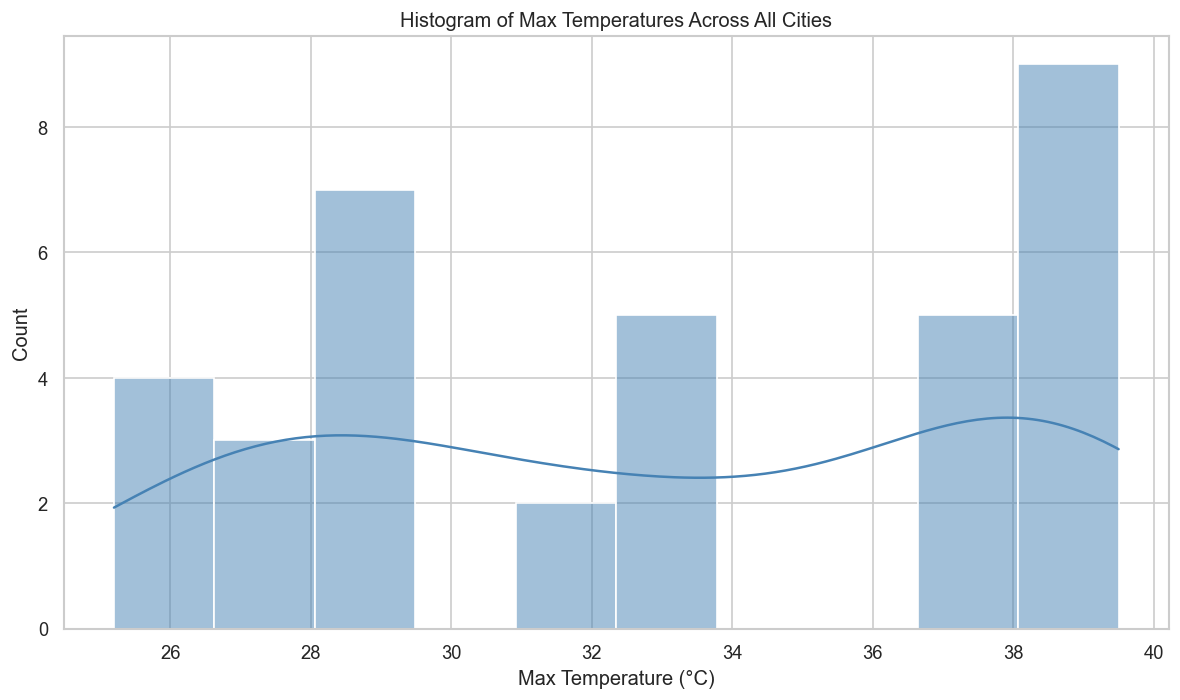

Saved histogram to max_temp_histogram.png
If the shape looks roughly bell-shaped, it is closer to normal.


In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(analysis_df["max_temp"], bins=10, kde=True, color="steelblue")
plt.title("Histogram of Max Temperatures Across All Cities")
plt.xlabel("Max Temperature (°C)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(CHART_HIST, dpi=150)
plt.show()

print(f"Saved histogram to {CHART_HIST}")
print("If the shape looks roughly bell-shaped, it is closer to normal.")

## 6) Plot side-by-side box plots by city

This chart compares the spread, median, and possible outliers for max temperature in each city.

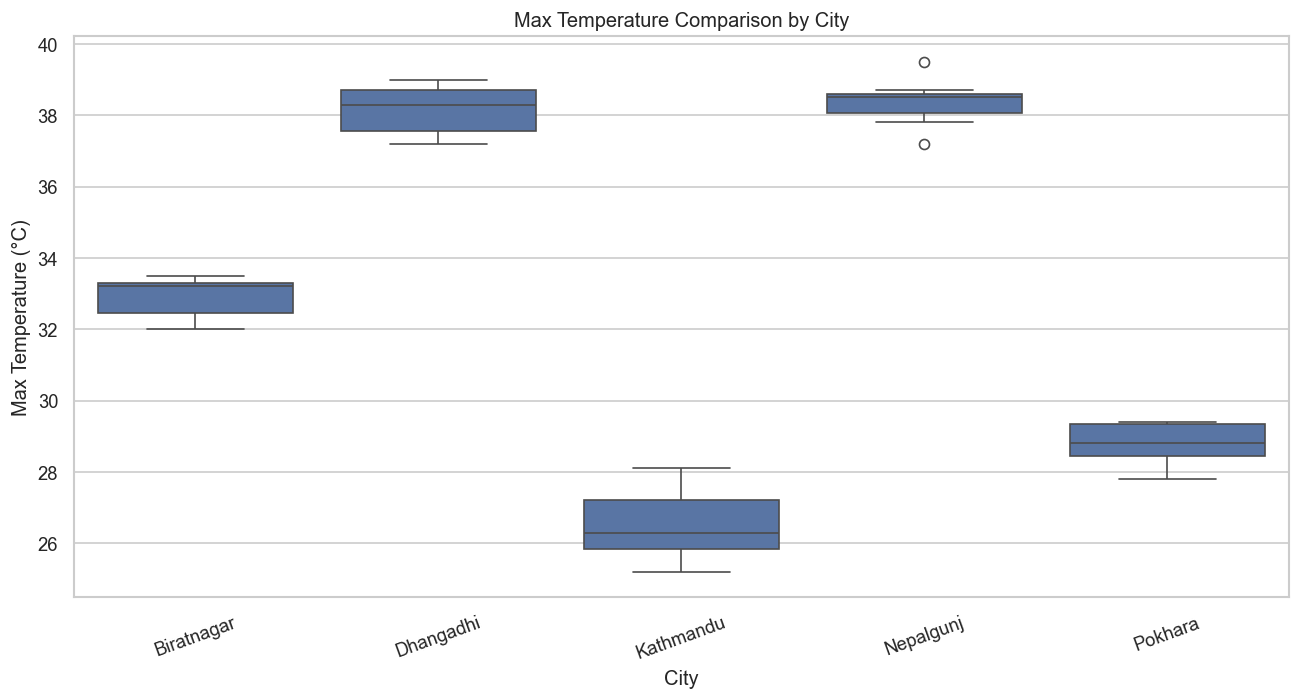

Saved box plot to max_temp_boxplot_by_city.png


In [13]:
plt.figure(figsize=(11, 6))
# Compare the spread and the median for each city.
sns.boxplot(data=analysis_df, x="city", y="max_temp")
plt.title("Max Temperature Comparison by City")
plt.xlabel("City")
plt.ylabel("Max Temperature (°C)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_BOX, dpi=150)
plt.show()

print(f"Saved box plot to {CHART_BOX}")

## 7) Detect outliers with the IQR method

We check each city separately so we can see which days are unusually high or low compared with that city's own weather pattern.

In [14]:
outlier_rows = []

for city_name, group in analysis_df.groupby("city"):
    q1 = group["max_temp"].quantile(0.25)
    q3 = group["max_temp"].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    city_outliers = group[(group["max_temp"] < lower_limit) | (group["max_temp"] > upper_limit)].copy()
    if not city_outliers.empty:
        city_outliers["q1"] = q1
        city_outliers["q3"] = q3
        city_outliers["iqr"] = iqr
        city_outliers["lower_limit"] = lower_limit
        city_outliers["upper_limit"] = upper_limit
        outlier_rows.append(city_outliers)

if outlier_rows:
    outliers_df = pd.concat(outlier_rows, ignore_index=True)
    print("Outlier rows found with the IQR method:")
    print(outliers_df[["city", "date", "max_temp", "q1", "q3", "iqr", "lower_limit", "upper_limit"]])
else:
    outliers_df = pd.DataFrame()
    print("No outlier rows were found with the IQR method.")

Outlier rows found with the IQR method:
        city        date  max_temp     q1    q3   iqr  lower_limit  \
0  Nepalgunj  2026-05-19      37.2  38.05  38.6  0.55       37.225   
1  Nepalgunj  2026-05-23      39.5  38.05  38.6  0.55       37.225   

   upper_limit  
0       39.425  
1       39.425  


## 8) Plot KDE curves for all cities

This chart shows the temperature spread for each city on the same figure, which makes it easier to compare how wide or narrow each distribution is.

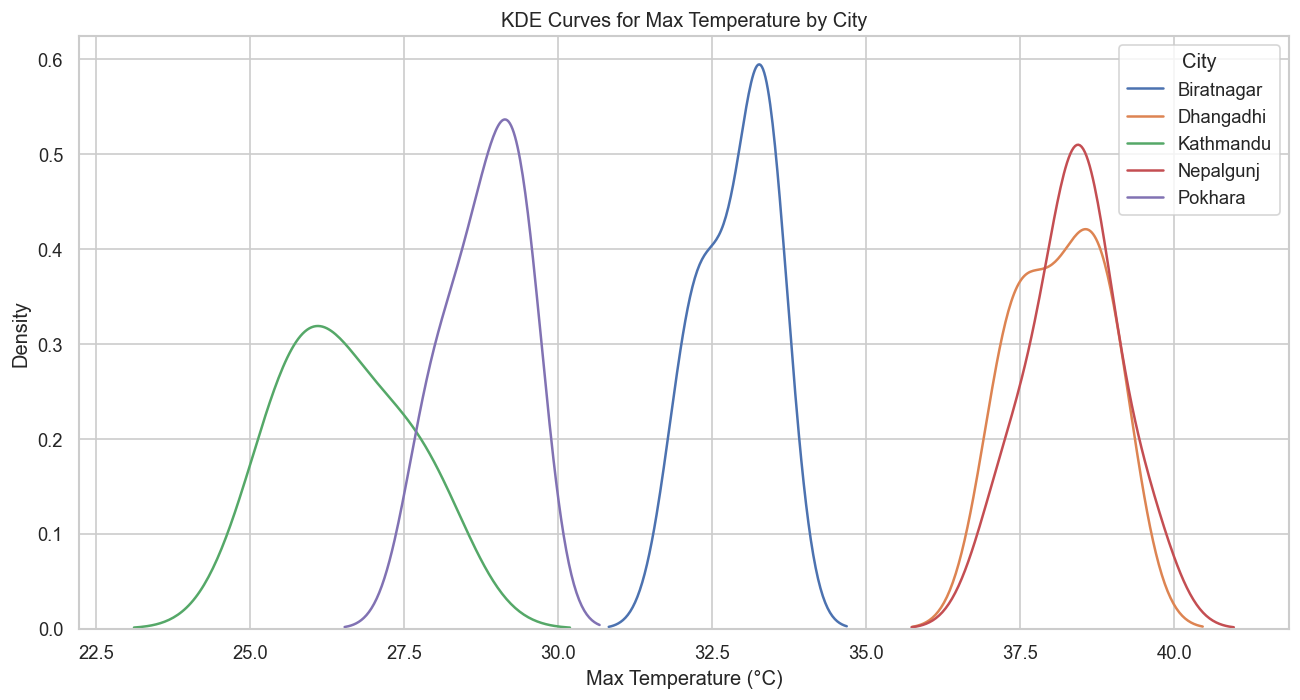

Saved KDE chart to max_temp_kde_by_city.png


In [15]:
plt.figure(figsize=(11, 6))
for city_name in analysis_df["city"].unique():
    subset = analysis_df[analysis_df["city"] == city_name]
    sns.kdeplot(data=subset, x="max_temp", label=city_name, fill=False)

plt.title("KDE Curves for Max Temperature by City")
plt.xlabel("Max Temperature (°C)")
plt.ylabel("Density")
plt.legend(title="City")
plt.tight_layout()
plt.savefig(CHART_KDE, dpi=150)
plt.show()

print(f"Saved KDE chart to {CHART_KDE}")

## 9) Build the grouped summary table

Here we calculate the mean, median, standard deviation, minimum, and maximum max temperature per city.

In [16]:
summary_table = (
    analysis_df.groupby("city")["max_temp"]
    .agg(["mean", "median", "std", "min", "max"])
    .round(2)
)

print(summary_table)

             mean  median   std   min   max
city                                       
Biratnagar  32.89    33.2  0.58  32.0  33.5
Dhangadhi   38.14    38.3  0.72  37.2  39.0
Kathmandu   26.53    26.3  1.03  25.2  28.1
Nepalgunj   38.36    38.5  0.72  37.2  39.5
Pokhara     28.80    28.8  0.62  27.8  29.4


## 10) Analyze rainfall as a bonus column

Rainfall is optional, but Open-Meteo provides it in the same daily forecast. We compare the cities with a simple bar chart.

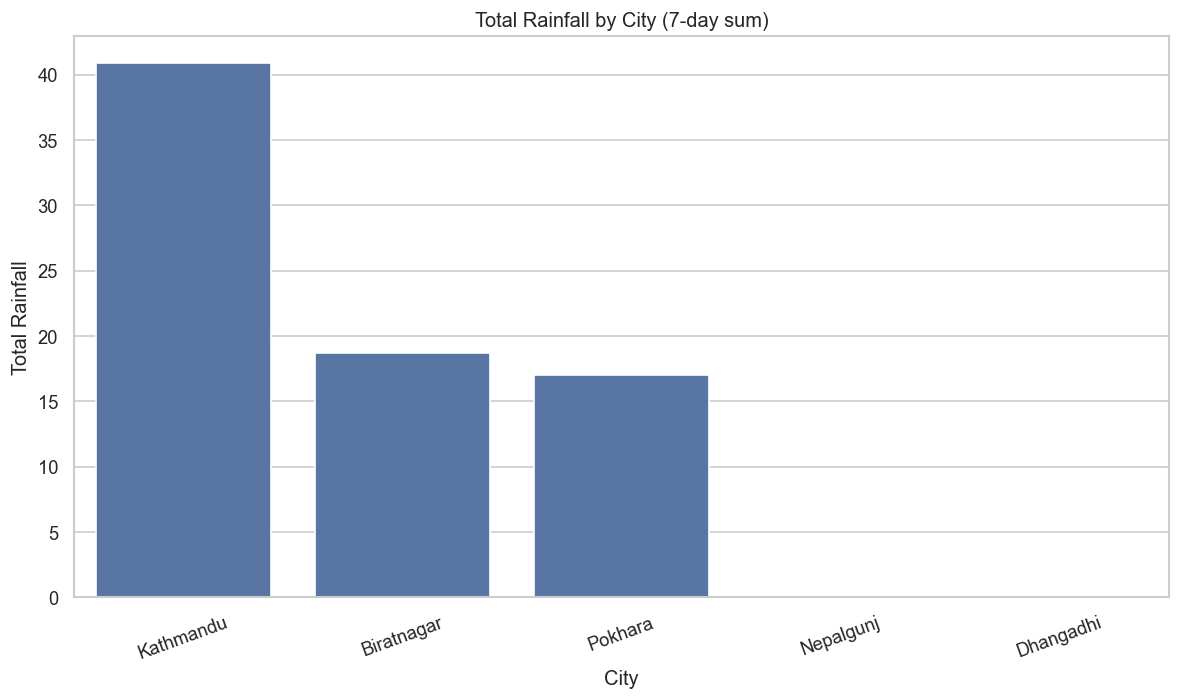

         city  total_rainfall
0   Kathmandu            40.9
1  Biratnagar            18.7
2     Pokhara            17.0
3   Nepalgunj             0.1
4   Dhangadhi             0.0
Saved rainfall chart to rainfall_by_city.png


In [18]:
rainfall_table = (
    analysis_df.groupby("city")["rainfall"]
    .sum()
    .sort_values(ascending=False)
    .reset_index(name="total_rainfall")
)

plt.figure(figsize=(10, 6))
# Show the 7-day rainfall total for each city.
sns.barplot(data=rainfall_table, x="city", y="total_rainfall")
plt.title("Total Rainfall by City (7-day sum)")
plt.xlabel("City")
plt.ylabel("Total Rainfall")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(CHART_RAIN, dpi=150)
plt.show()

print(rainfall_table)
print(f"Saved rainfall chart to {CHART_RAIN}")

## 11) Five observations from the analysis

The final cell prints five short observations based on the actual results from the dataset, plots, and summary tables.

In [19]:
city_spread_table = summary_table.copy()
widest_spread_city = city_spread_table["std"].idxmax()
widest_spread_value = city_spread_table.loc[widest_spread_city, "std"]
most_stable_city = city_spread_table["std"].idxmin()
most_stable_value = city_spread_table.loc[most_stable_city, "std"]
outlier_count = len(outliers_df)

combined_skew = analysis_df["max_temp"].skew()
if combined_skew > 0.5:
    distribution_note = "right-skewed"
elif combined_skew < -0.5:
    distribution_note = "left-skewed"
else:
    distribution_note = "fairly balanced"

print("Five observations from the analysis:\n")
print(f"1. The combined max-temperature distribution looks {distribution_note} with skewness of {combined_skew:.2f}.")
print(f"2. {widest_spread_city} has the widest spread in max temperature based on standard deviation ({widest_spread_value:.2f}).")
print(f"3. {most_stable_city} is the most stable city because it has the smallest standard deviation ({most_stable_value:.2f}).")
print(f"4. The IQR check found {outlier_count} outlier row(s) in the max-temperature data.")
print(f"5. Rainfall can be compared by city using the bonus chart, and {rainfall_table.iloc[0]['city']} recorded the highest total rainfall in this 7-day period.")

Five observations from the analysis:

1. The combined max-temperature distribution looks fairly balanced with skewness of -0.08.
2. Kathmandu has the widest spread in max temperature based on standard deviation (1.03).
3. Biratnagar is the most stable city because it has the smallest standard deviation (0.58).
4. The IQR check found 2 outlier row(s) in the max-temperature data.
5. Rainfall can be compared by city using the bonus chart, and Kathmandu recorded the highest total rainfall in this 7-day period.
